# Práctica evaluación módulo 'Machine Learning y Deep Learning

## 0. Configuración Notebook

### Importación librerías

In [10]:
import pandas as pd
from matplotlib import pyplot as plt

### Definición constantes

In [2]:
DATA_DIR = './data'

In [3]:
DATASET = f'{DATA_DIR}/dataset_practica_final.csv'

### Definición funciones

In [4]:
def compare_scores(model_list, y_test, X_test):
    '''
    muestra un dataframe con índice por modelo y columnas por métrica, valores el valor de la métrica
    '''
    pass

In [5]:
def plot_ROC(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo del ROC
    '''
    pass

In [6]:
def plot_confusion_matrix(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo de la confusion_matrix
    '''
    pass

## 1. Carga y pre-procesamiento de datos

### Carga y copia

In [7]:
dset = pd.read_csv(DATASET)
dset_cp = dset.copy()

### Inspección

## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

### *Cosas a ver*:
- si está balanceado
- identificar outlayers
- identificar datos faltantes
- sacar correlaciones
- sacar pca 


In [37]:
dset_cp.info()
# reservation_status y reservation_status_date fuera, en tanto que la primera da información que duplica o es posterior al target y la segunda es un atributo de la primera

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
dset_cp.drop(['reservation_status', 'reservation_status_date'], axis=1, inplace=True)

In [9]:
dset_cp['is_canceled'].value_counts()
# el dataset está balanceado

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [55]:
dset_cp.isna().sum()[dset_cp.isna().sum() > 0]
# country: sustituir na por 'unknown'. muchos menos na que na: vale la pena conservarla, ya que a pesar de los na sigue aportando iformación
# agent: sustituir na por 'unknown'
# company: más na que no na (muchos más): se elimina. no aporta infor

children         4
country        488
agent        16340
company     112593
dtype: int64

In [56]:
dset_cp.drop(['company'], axis=1, inplace=True)

/tmp/ipykernel_461/1020883537.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


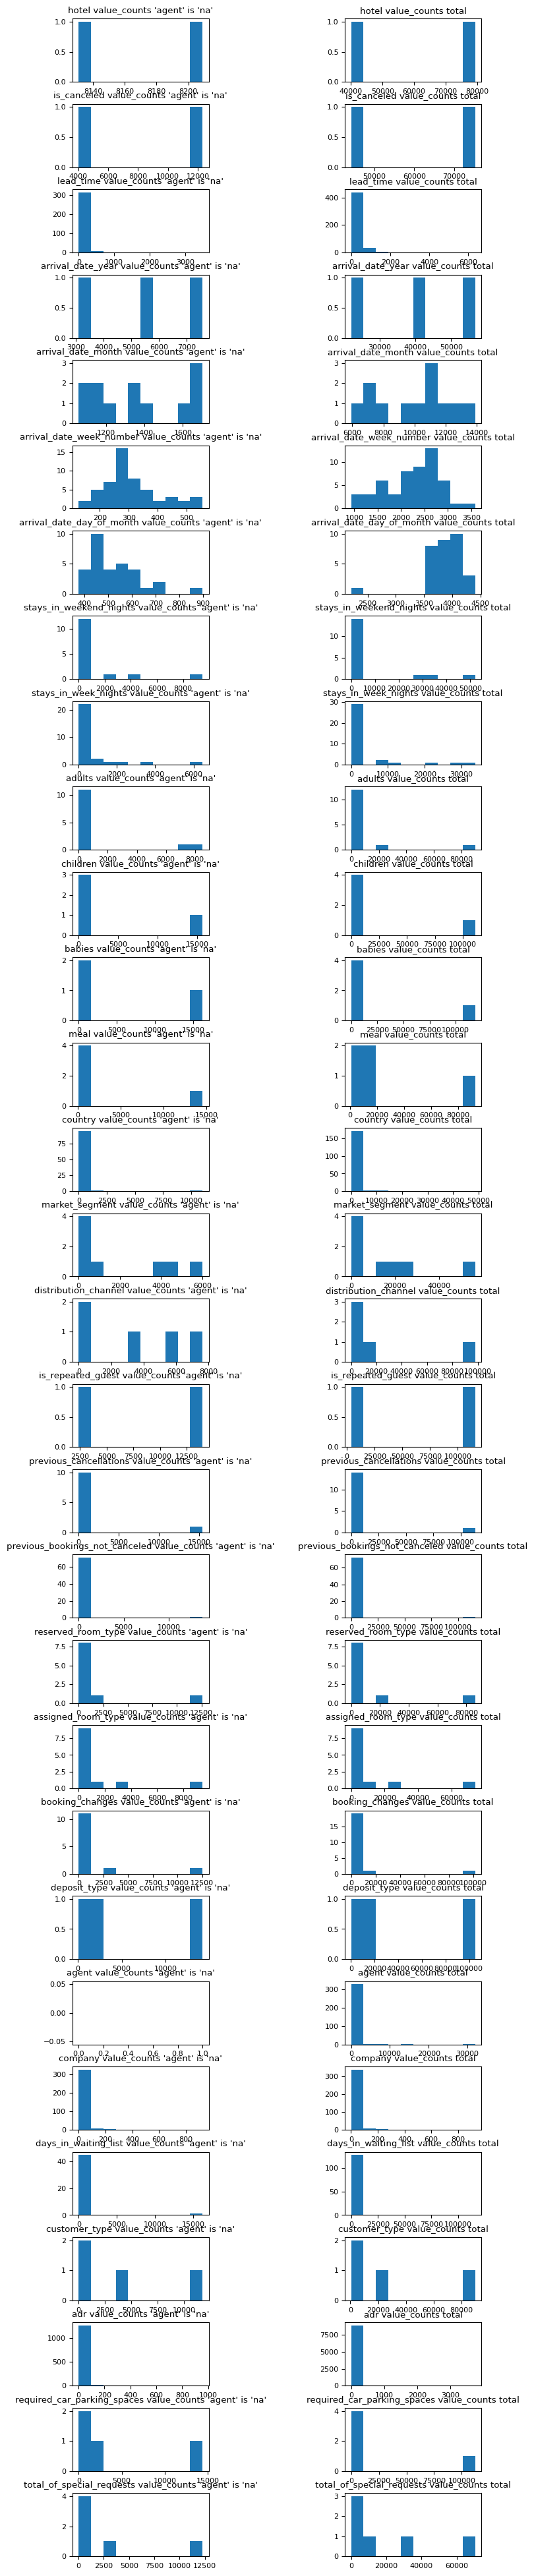

In [51]:
i=0
fig, ax = plt.subplots(nrows = len(dset_cp.columns), ncols=2, figsize=(8,50))
plt.subplots_adjust(hspace=0.35, wspace=1)
plt.rc({'font.size':6})
for c in dset_cp.columns:
    ax[i,0].hist(dset_cp[dset_cp['agent'].isna()][c].dropna().value_counts())
    ax[i,0].set_title(f"{c} value_counts 'agent' is 'na'")
    ax[i,1].hist(dset_cp[c].dropna().value_counts())
    ax[i,1].set_title(f"{c} value_counts total")
    i +=1
fig.show()

# se comparan los value conuts de las columnas dependiendo se si se filtran fuera las filas con 'agent' a 'na' o no, por ver si los 'na' están uniformemente distribuidos o no, 
# es deicir, si el valor 'na' en 'agent' contiene información. 
# se ve que la mayor relación es con estas columnas: arrival_date_month, arrival_date_week, arrival_day_of_month, distribution_channel

In [ ]:
- reservation date: 

In [14]:
dset_cp.head().T

,0,1,2,3,4
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2015,2015,2015,2015,2015
arrival_date_month,July,July,July,July,July
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_week_nights,0,0,1,1,2
adults,2,2,1,1,2


### Pre-procesiamiento

## *cosas a hacer:*
- quitar variables no importantes o que distorsionan
- quitar o imputar datos
- estandarizar
- codificar categóricas

## 2. Entrenamiento (incluye selección de hiperparámetros)

### 2.1 Logistic Regression

### 2.2 DecisionTree

### 2.3 Random Forest

### 2.4 XGBoost

### 2.5 Multilayer Neural Network

In [ ]:
## 3. Comparativa Modelos